## 

# Data Preprocessing

In [1]:
import numpy as np
import shap

print("NumPy:", np.__version__)
print("SHAP:", shap.__version__)


NumPy: 1.23.5
SHAP: 0.41.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split


In [3]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level'
]

categories = {
    # DoS (Denial of Service) → goal = make a service unavailable.
    "DoS": ["back", "land", "neptune", "pod", "smurf", "teardrop", "apache2", "udpstorm", "processtable", "mailbomb", "worm"],
    # Probe (Surveillance / Scanning) → goal = gather information about the target.
    "Probe": ["satan", "ipsweep", "nmap", "portsweep", "mscan", "saint"],
    # R2L (Remote to Local) → attacker has no account, tries to gain local access.
    "R2L": ["guess_passwd", "ftp_write", "imap", "phf", "multihop", "warezmaster", "warezclient", "spy", "xlock", "xsnoop", "snmpguess", "snmpgetattack", "httptunnel", "sendmail", "named", "worm"],
    # U2R (User to Root) → attacker already has user access, then escalates to root/admin.
    "U2R": ["buffer_overflow", "loadmodule", "perl", "rootkit", "ps", "sqlattack", "xterm"],
    "Normal": ["normal"]
}

def categorising(attack):
    for cat, attacks in categories.items():
        if attack in attacks:
            return cat
    return 'other'

print("-->Configuration ready")

-->Configuration ready


In [4]:
train_path = "D:\Assignments\capstone project\dataset\KDDTrain+.txt"
test_path = "D:\Assignments\capstone project\dataset\KDDTest+.txt"

df_train = pd.read_csv(train_path, names=columns)
df_test = pd.read_csv(test_path, names=columns)
df = pd.concat([df_test, df_train], ignore_index= True)

print(f"train:{df_train.shape}\ntest:{df_test.shape}")

train:(125973, 43)
test:(22544, 43)


In [5]:
df_train['category'] = df_train['attack'].apply(categorising)
df_test['category'] = df_test['attack'].apply(categorising)
df['category'] = df['attack'].apply(categorising)

In [6]:
print(df[['attack', 'category']].head(10))
print(df['category'].value_counts())

         attack category
0       neptune      DoS
1       neptune      DoS
2        normal   Normal
3         saint    Probe
4         mscan    Probe
5        normal   Normal
6        normal   Normal
7  guess_passwd      R2L
8        normal   Normal
9  guess_passwd      R2L
category
Normal    77054
DoS       53387
Probe     14077
R2L        3880
U2R         119
Name: count, dtype: int64


In [7]:
# Binary label for IDS detection
# 0 = Normal, 1 = Attack

df['label'] = df['category'].apply(lambda x: 0 if x == 'Normal' else 1)

print(df['label'].value_counts())

label
0    77054
1    71463
Name: count, dtype: int64


In [8]:
X = df.drop(['attack', 'category', 'label'], axis=1)
y = df['label']

In [9]:
X = pd.get_dummies(
    X,
    columns=['protocol_type', 'service', 'flag'],
    drop_first=True
)


# Model Training

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Performance metrics

In [12]:
# Generate predictions again
y_pred = rf.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.93%


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     15411
      Attack       1.00      1.00      1.00     14293

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[15393    18]
 [    4 14289]]


# Prediction

In [16]:
y_pred = rf.predict(X_test)

In [17]:
results = X_test.copy()
results['Predicted_Label'] = y_pred
results['True_Label'] = y_test.values

# bring back attack category for interpretation
results['Attack_Category'] = df.loc[X_test.index, 'category']


In [18]:
results_display = results[
    results['Predicted_Label'] == 1
][['Predicted_Label', 'Attack_Category']].head(10)

print(results_display)


        Predicted_Label Attack_Category
8106                  1             R2L
6010                  1             DoS
72440                 1             DoS
134941                1             DoS
43737                 1           Probe
131897                1           Probe
14280                 1             DoS
16349                 1             DoS
127947                1             DoS
23746                 1             DoS


In [19]:
def alert_message(row):
    if row['Predicted_Label'] == 1:
        return f"🚨 ATTACK DETECTED | Type: {row['Attack_Category']}"
    else:
        return "✅ Normal Traffic"

results['Alert'] = results.apply(alert_message, axis=1)
print(results[['Alert']].head(10))


                                  Alert
8106      🚨 ATTACK DETECTED | Type: R2L
6010      🚨 ATTACK DETECTED | Type: DoS
57072                  ✅ Normal Traffic
72440     🚨 ATTACK DETECTED | Type: DoS
134941    🚨 ATTACK DETECTED | Type: DoS
43737   🚨 ATTACK DETECTED | Type: Probe
131897  🚨 ATTACK DETECTED | Type: Probe
14280     🚨 ATTACK DETECTED | Type: DoS
16349     🚨 ATTACK DETECTED | Type: DoS
19252                  ✅ Normal Traffic


# Integration with SHAP AI

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

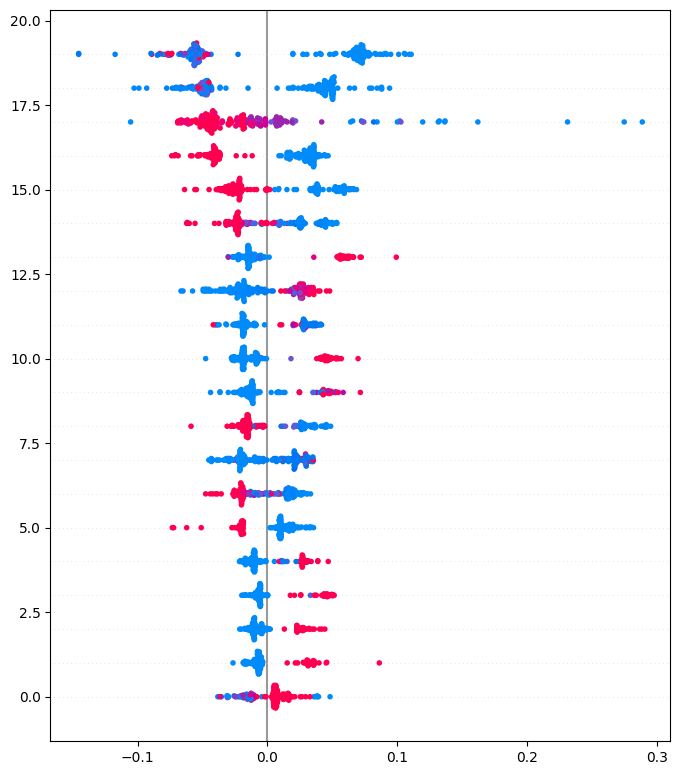

In [20]:
import shap

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf)

# Sample for explanation
X_sample = X_test.iloc[:200]

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Global explanation (Attack class)
shap.summary_plot(shap_values[1], X_sample)


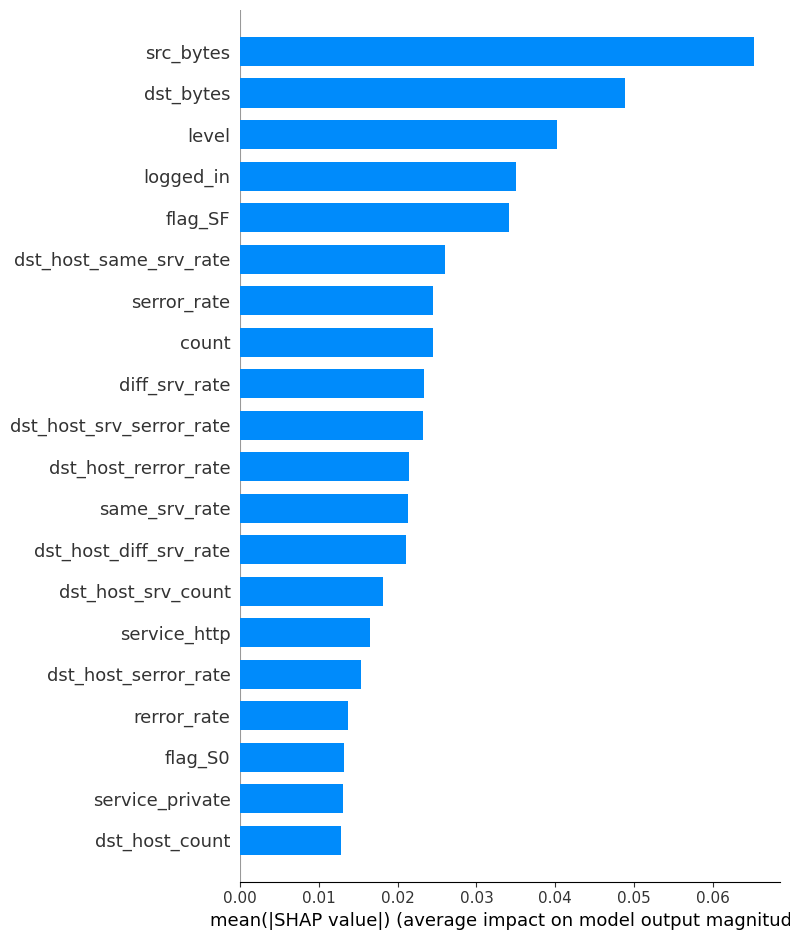

In [21]:
shap.summary_plot(
    shap_values[1],
    X_sample,
    plot_type="bar",
    show=True
)


In [22]:
train_attacks= df_train['attack'].unique().size
test_attacks= df_test['attack'].unique().size
print(f"attack types in train dataset : {train_attacks} ")
print(f"attack types in test dataset : {test_attacks} ")

attack types in train dataset : 23 
attack types in test dataset : 38 


In [23]:
unknown_attacks = df_test.loc[~df_test['attack'].isin(df_train['attack']), 'attack'].unique()
print(unknown_attacks)

['saint' 'mscan' 'apache2' 'snmpgetattack' 'processtable' 'httptunnel'
 'ps' 'snmpguess' 'mailbomb' 'named' 'sendmail' 'xterm' 'worm' 'xlock'
 'xsnoop' 'sqlattack' 'udpstorm']


# Exploratary Data Analysis

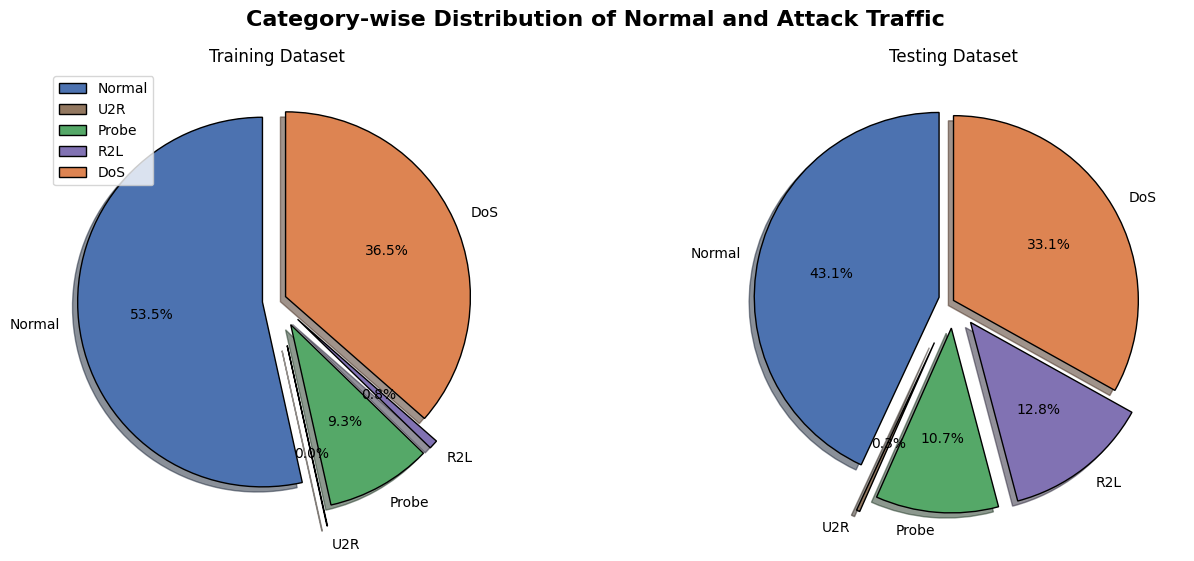

In [24]:
df_train['is_attack']= (df_train['attack'] != "normal").astype(int)
df_test['is_attack']= (df_test['attack'] != "normal").astype(int)

ordered_categories= ['Normal', 'U2R', 'Probe', 'R2L', 'DoS']
train_dis = df_train["category"].value_counts().reindex(ordered_categories)
test_dis = df_test["category"].value_counts().reindex(ordered_categories)

palette = {
    "Normal": "#4C72B0",   # muted blue
    "DoS": "#DD8452",      # muted orange
    "Probe": "#55A868",    # soft green
    "R2L": "#8172B3",      # muted purple
    "U2R": "#937860"       # brown/bronze
}

fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].pie(
    train_dis,
    autopct='%1.1f%%',
    labels=ordered_categories,
    startangle=90,
    colors=[palette[cat] for cat in ordered_categories],
    explode=(0.08, 0.25, 0.15, 0.15, 0.05),
    shadow=True,
    wedgeprops={'edgecolor': 'black'}
)
axes[0].set_title('Training Dataset')
axes[0].legend(loc="upper left")

axes[1].pie(
    test_dis,
    autopct='%1.1f%%',
    labels=ordered_categories,
    startangle=90,
    colors=[palette[cat] for cat in ordered_categories],
    explode=(0.08, 0.25, 0.15, 0.15, 0),
    shadow=True,
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Testing Dataset')

plt.suptitle(
    'Category-wise Distribution of Normal and Attack Traffic',
    fontsize=16,
    fontweight="bold"
)
plt.show()




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



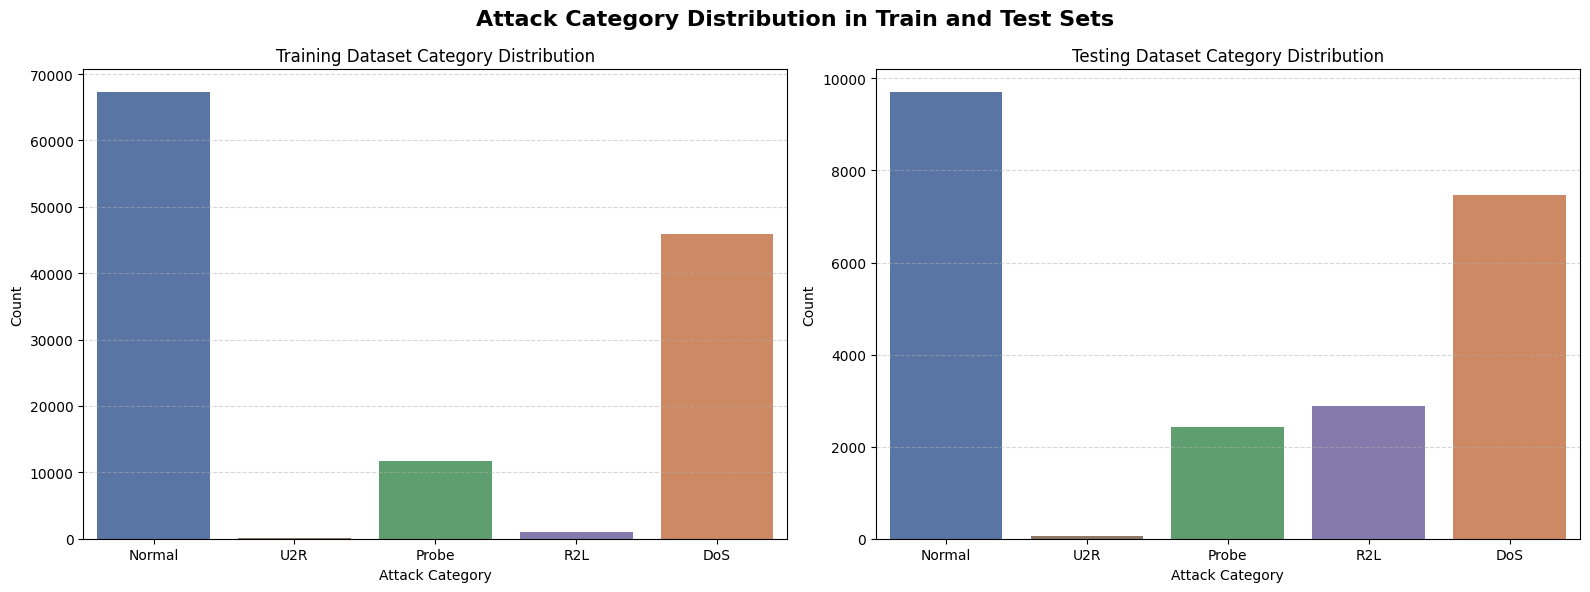

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.countplot(
    data=df_train,
    x="category",
    order=ordered_categories,
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("Training Dataset Category Distribution")
axes[0].set_xlabel("Attack Category")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

sns.countplot(
    data=df_test,
    x="category",
    order=ordered_categories,
    palette=palette,
    ax=axes[1]
)
axes[1].set_title("Testing Dataset Category Distribution")
axes[1].set_xlabel("Attack Category")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Attack Category Distribution in Train and Test Sets",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


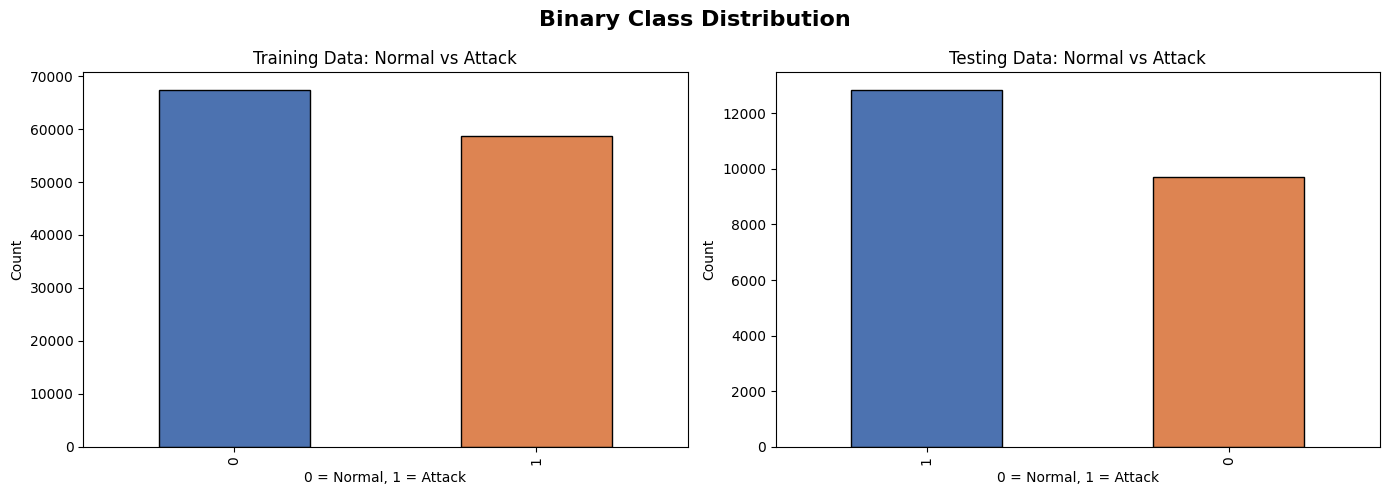

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df_train["is_attack"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["#4C72B0", "#DD8452"],
    edgecolor="black"
)
axes[0].set_title("Training Data: Normal vs Attack")
axes[0].set_xlabel("0 = Normal, 1 = Attack")
axes[0].set_ylabel("Count")

df_test["is_attack"].value_counts().plot(
    kind="bar",
    ax=axes[1],
    color=["#4C72B0", "#DD8452"],
    edgecolor="black"
)
axes[1].set_title("Testing Data: Normal vs Attack")
axes[1].set_xlabel("0 = Normal, 1 = Attack")
axes[1].set_ylabel("Count")

plt.suptitle("Binary Class Distribution",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



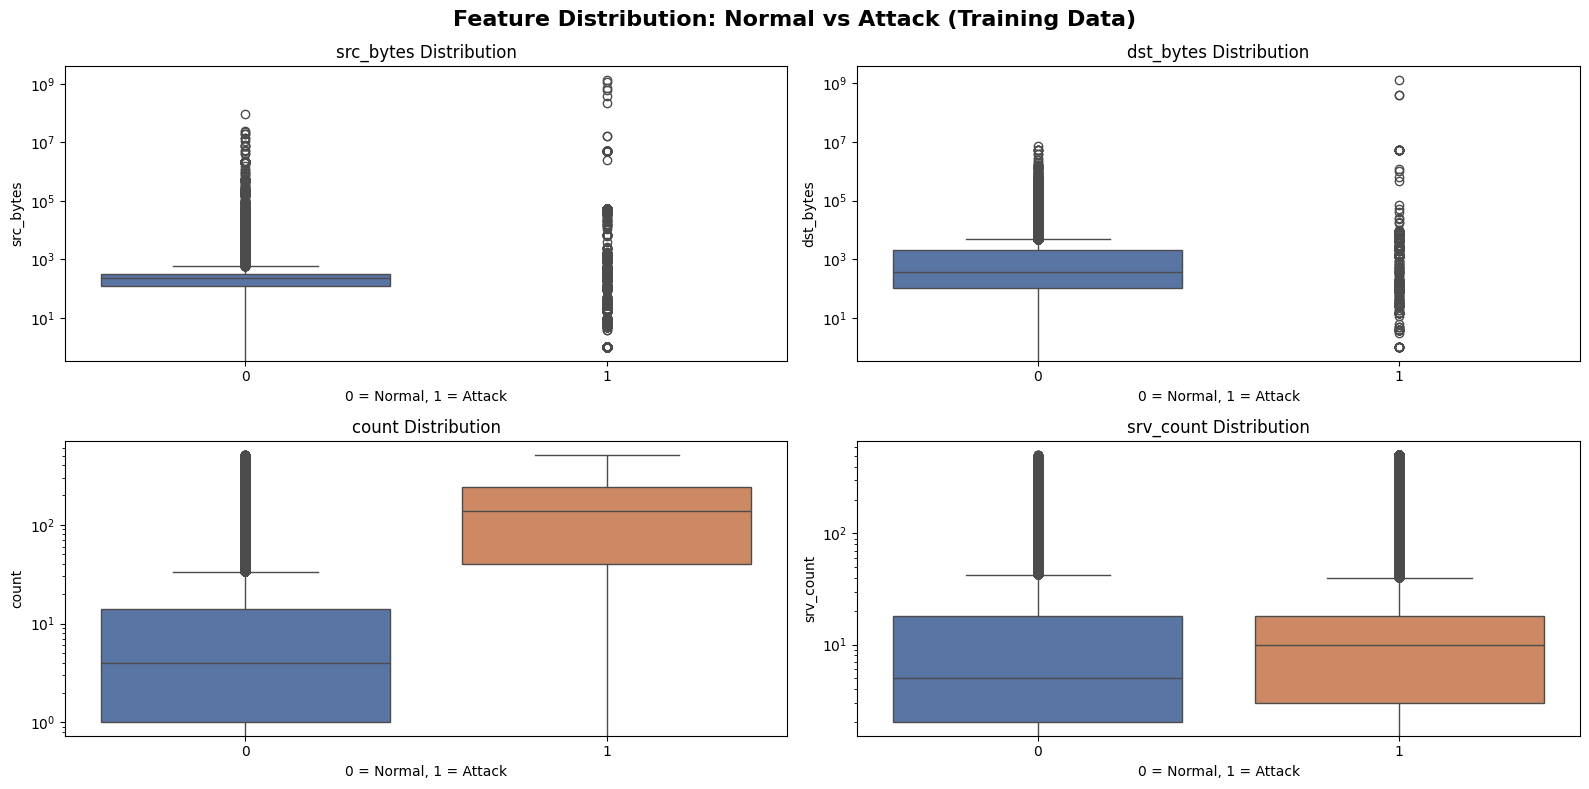

In [27]:
features_to_plot = ["src_bytes", "dst_bytes", "count", "srv_count"]

plt.figure(figsize=(16,8))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        data=df_train,
        x="is_attack",
        y=feature,
        palette=["#4C72B0", "#DD8452"]
    )
    plt.title(f"{feature} Distribution")
    plt.xlabel("0 = Normal, 1 = Attack")
    plt.yscale("log")  # IMPORTANT for network traffic

plt.suptitle("Feature Distribution: Normal vs Attack (Training Data)",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


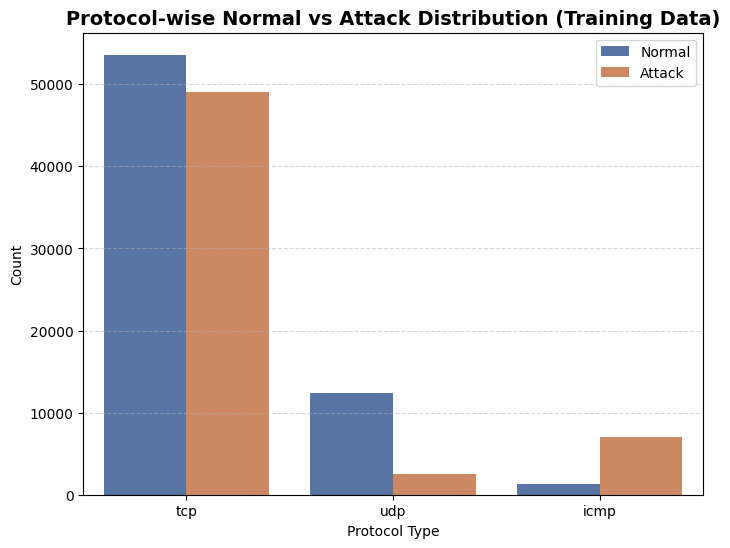

In [28]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df_train,
    x="protocol_type",
    hue="is_attack",
    palette=["#4C72B0", "#DD8452"]
)

plt.title("Protocol-wise Normal vs Attack Distribution (Training Data)",
          fontsize=14, fontweight="bold")
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.legend(["Normal", "Attack"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


In [29]:
attack_x_protocol= df.groupby(['protocol_type', 'category'])['category'].value_counts().unstack(fill_value=0)
attack_x_protocol_pct = attack_x_protocol.div(attack_x_protocol.sum(axis=0), axis=1) * 100
attack_x_protocol_pct

category,DoS,Normal,Probe,R2L,U2R
protocol_type,,,,,
icmp,6.655178,1.819503,31.079065,0.103093,0.000000
tcp,91.647779,79.738884,54.848334,86.649485,97.478992
udp,1.697042,18.441612,14.072601,13.247423,2.521008


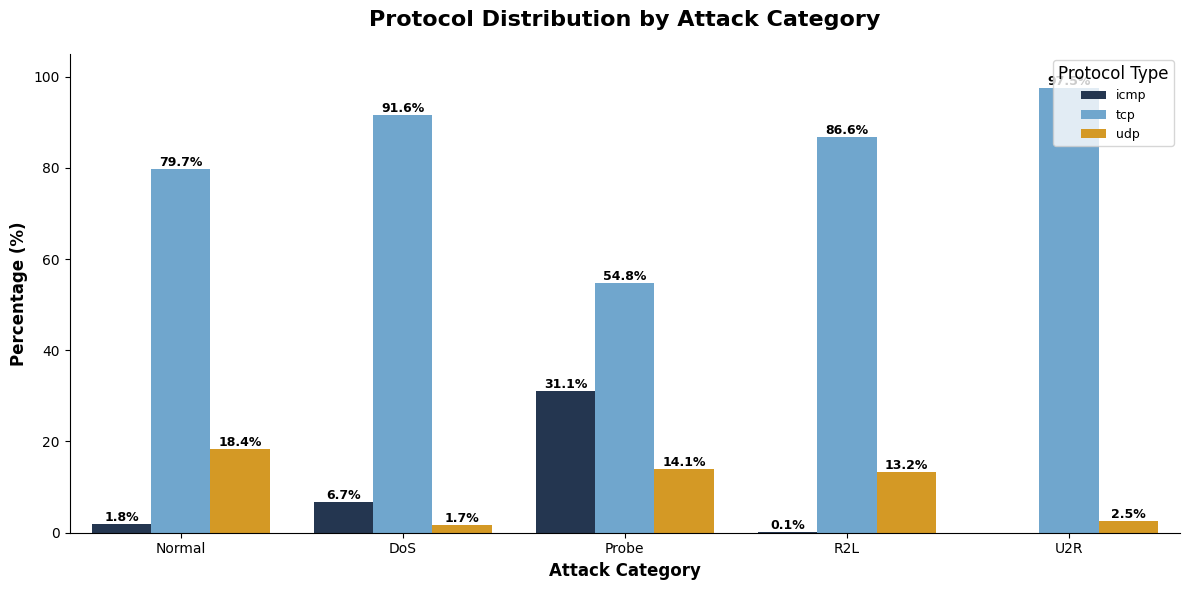

In [30]:
# Prepare data for plotting - properly reset index
attack_x_protocol_pct_reset = attack_x_protocol_pct.reset_index()


# Melt the dataframe for seaborn barplot
plot_data = attack_x_protocol_pct_reset.melt(
    id_vars='protocol_type', 
    var_name='Attack Category', 
    value_name='Percentage'
)

# Create the grouped bar plot
plt.figure(figsize=(12, 6))
colors = ["#1D3557", "#60A9DD", "#F1A208"]  # Navy, Red, Gold


ax = sns.barplot(data=plot_data, x='Attack Category', y='Percentage', hue='protocol_type', palette=colors, order=['Normal', 'DoS', 'Probe', 'R2L', 'U2R'])

# Add percentage labels on bars
for container in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, fontsize=9, fontweight='bold')

# Styling
plt.title("Protocol Distribution by Attack Category", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Attack Category", fontsize=12, fontweight='bold')
plt.ylabel("Percentage (%)", fontsize=12, fontweight='bold')
plt.ylim(0, 105)

plt.legend(title='Protocol Type', fontsize=9, title_fontsize=12, loc='upper right')

sns.despine()
plt.tight_layout()

# Integration with Explainable AI

In [31]:
# Pick one detected attack instance
attack_idx = (y_pred == 1)
X_one = X_test[attack_idx].iloc[0:1]

# Compute SHAP values
shap_values_one = explainer.shap_values(X_one)[1][0]


In [32]:
shap_df = pd.DataFrame({
    "feature": X_one.columns,
    "shap_value": shap_values_one
})

# Sort by importance
shap_df = shap_df.sort_values(
    by="shap_value",
    key=abs,
    ascending=False
)

shap_df.head(6)


,feature,shap_value
38,level,0.274844
87,service_pop_3,0.126373
36,dst_host_rerror_rate,0.042781
1,src_bytes,0.037438
0,duration,0.028556
2,dst_bytes,0.026931


In [33]:
top_features = shap_df.head(4)

explanation = "Attack detected due to abnormal behavior in the following features:\n"

for _, row in top_features.iterrows():
    direction = "increases" if row["shap_value"] > 0 else "decreases"
    explanation += f"- {row['feature']} {direction} the likelihood of an attack\n"

print(explanation)


Attack detected due to abnormal behavior in the following features:
- level increases the likelihood of an attack
- service_pop_3 increases the likelihood of an attack
- dst_host_rerror_rate increases the likelihood of an attack
- src_bytes increases the likelihood of an attack



In [34]:
attack_type = df.loc[X_one.index, "category"].values[0]

print(f"🚨 ATTACK DETECTED")
print(f"Type: {attack_type}")
print(explanation)


🚨 ATTACK DETECTED
Type: R2L
Attack detected due to abnormal behavior in the following features:
- level increases the likelihood of an attack
- service_pop_3 increases the likelihood of an attack
- dst_host_rerror_rate increases the likelihood of an attack
- src_bytes increases the likelihood of an attack



## Using Dense AutoEncoders

In [35]:
pip install tensorflow==2.10.1 protobuf==3.19.6

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import tensorflow as tf
print(tf.__version__)


You are using a Python version (3.10.6) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.


2.10.1


In [37]:
# Train autoencoder ONLY on normal traffic
ae_X_train = X_train[y_train == 0]
ae_X_test  = X_test


In [38]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

ae_input_dim = ae_X_train.shape[1]

ae_input = Input(shape=(ae_input_dim,))

ae_encoded = Dense(128, activation='relu')(ae_input)
ae_encoded = Dense(64, activation='relu')(ae_encoded)
ae_encoded = Dense(32, activation='relu')(ae_encoded)

ae_decoded = Dense(64, activation='relu')(ae_encoded)
ae_decoded = Dense(128, activation='relu')(ae_decoded)
ae_output = Dense(ae_input_dim, activation='linear')(ae_decoded)

ae_model = Model(inputs=ae_input, outputs=ae_output)

ae_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

ae_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 120)]             0         
                                                                 
 dense (Dense)               (None, 128)               15488     
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 64)                2112      
                                                                 
 dense_4 (Dense)             (None, 128)               8320      
                                                                 
 dense_5 (Dense)             (None, 120)               15480 

In [39]:
ae_X_train.dtypes

duration          int64
src_bytes         int64
dst_bytes         int64
land              int64
wrong_fragment    int64
                  ...  
flag_S1            bool
flag_S2            bool
flag_S3            bool
flag_SF            bool
flag_SH            bool
Length: 120, dtype: object

Feature normalization ensured uniform contribution of all attributes, while threshold tuning aligned anomaly detection sensitivity with the distribution of normal traffic, significantly improving detection performance.

In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Normal-only for AE
ae_X_train_np = X_train_scaled[y_train == 0].astype('float32')
ae_X_test_np  = X_test_scaled.astype('float32')


In [41]:
ae_history = ae_model.fit(
    ae_X_train_np,
    ae_X_train_np,
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/100
217/217 [==============================] - 1s 2ms/step - loss: 0.0097 - val_loss: 0.0017
Epoch 2/100
217/217 [==============================] - 0s 2ms/step - loss: 0.0011 - val_loss: 7.4333e-04
Epoch 3/100
217/217 [==============================] - 0s 2ms/step - loss: 6.1888e-04 - val_loss: 5.1018e-04
Epoch 4/100
217/217 [==============================] - 0s 2ms/step - loss: 4.4540e-04 - val_loss: 3.7596e-04
Epoch 5/100
217/217 [==============================] - 0s 2ms/step - loss: 3.4494e-04 - val_loss: 3.0862e-04
Epoch 6/100
217/217 [==============================] - 0s 2ms/step - loss: 2.8209e-04 - val_loss: 2.5374e-04
Epoch 7/100
217/217 [==============================] - 0s 2ms/step - loss: 2.4137e-04 - val_loss: 2.2608e-04
Epoch 8/100
217/217 [==============================] - 0s 2ms/step - loss: 2.1042e-04 - val_loss: 1.9332e-04
Epoch 9/100
217/217 [==============================] - 0s 2ms/step - loss: 1.8302e-04 - val_loss: 1.7820e-04
Epoch 10/100
217/217 [=========

In [42]:
ae_history = ae_model.fit(
    ae_X_train_np,
    ae_X_train_np,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/50
217/217 [==============================] - 0s 2ms/step - loss: 2.0794e-05 - val_loss: 3.6053e-05
Epoch 2/50
217/217 [==============================] - 0s 2ms/step - loss: 2.0322e-05 - val_loss: 3.9209e-05
Epoch 3/50
217/217 [==============================] - 0s 2ms/step - loss: 2.1188e-05 - val_loss: 3.6312e-05
Epoch 4/50
217/217 [==============================] - 0s 2ms/step - loss: 2.0609e-05 - val_loss: 3.9826e-05
Epoch 5/50
217/217 [==============================] - 0s 2ms/step - loss: 1.9176e-05 - val_loss: 3.7708e-05
Epoch 6/50
217/217 [==============================] - 0s 2ms/step - loss: 2.0254e-05 - val_loss: 3.9942e-05
Epoch 7/50
217/217 [==============================] - 0s 2ms/step - loss: 2.0818e-05 - val_loss: 3.7437e-05
Epoch 8/50
217/217 [==============================] - 0s 2ms/step - loss: 1.8901e-05 - val_loss: 3.6860e-05
Epoch 9/50
217/217 [==============================] - 0s 2ms/step - loss: 2.0296e-05 - val_loss: 3.4429e-05
Epoch 10/50
217/217 [=======

In [43]:
ae_X_test_pred = ae_model.predict(ae_X_test_np)

ae_reconstruction_error = np.mean(
    np.square(ae_X_test_np - ae_X_test_pred),
    axis=1
)


929/929 [==============================] - 2s 655us/step


In [44]:
normal_errors = ae_reconstruction_error[y_test == 0]


In [45]:
ae_threshold = np.percentile(normal_errors, 95)
print("Anomaly Threshold:", ae_threshold)


Anomaly Threshold: 3.187415859429166e-05


In [46]:
from sklearn.metrics import accuracy_score

ae_y_pred = (ae_reconstruction_error > ae_threshold).astype(int)

ae_accuracy = accuracy_score(y_test, ae_y_pred)
print(f"Dense Autoencoder Accuracy: {ae_accuracy * 100:.2f}%")


Dense Autoencoder Accuracy: 96.08%


In [47]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, ae_y_pred))
print(classification_report(y_test, ae_y_pred))


[[14640   771]
 [  393 13900]]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     15411
           1       0.95      0.97      0.96     14293

    accuracy                           0.96     29704
   macro avg       0.96      0.96      0.96     29704
weighted avg       0.96      0.96      0.96     29704



Although the supervised model achieves higher accuracy, the proposed autoencoder is capable of detecting unseen attacks without prior labeling.

In [48]:
df_train['attack_class'] = df_train['attack'].apply(categorising)
df_test['attack_class'] = df_test['attack'].apply(categorising)

print(df_train['attack_class'].value_counts())

attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [ ]:
X_train = df_train.drop(['attack', 'level', 'attack_class'], axis=1)
y_train = df_train['attack_class']

X_test = df_test.drop(['attack', 'level', 'attack_class'], axis=1)
y_test = df_test['attack_class']

In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_multi = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(X_train, y_train)

In [ ]:
y_pred_multi = rf_multi.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred_multi))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_multi)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Multi-Class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
sample = X_test.iloc[0:1]
pred = rf_multi.predict(sample)[0]

print(f"⚠️ Predicted Attack Type: {pred}")

## Automated Report Generation (PDF)

In [ ]:
!pip install reportlab

In [ ]:
sample = X_test.iloc[0:1]

proba = rf_multi.predict_proba(sample)
risk_score = max(proba[0]) * 100

attack_type = rf_multi.predict(sample)[0]

In [ ]:
shap_text = explanation

### plot

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure()
# df_train['attack_class'].value_counts().plot(kind='bar')
# plt.title("Attack Distribution")
# plt.xlabel("Attack Type")
# plt.ylabel("Count")
# plt.tight_layout()
# plt.savefig("attack_distribution.png")
# plt.close()

In [ ]:
# top_features = shap_df.head(6)

# plt.figure()
# plt.barh(top_features['feature'], top_features['shap_value'])
# plt.title("Top Features Influencing Attack")
# plt.xlabel("SHAP Value")
# plt.tight_layout()
# plt.savefig("shap_plot.png")
# plt.close()

In [ ]:
# plt.figure()
# plt.bar(["Risk"], [risk_score])
# plt.ylim(0,100)
# plt.title("Risk Score (%)")
# plt.tight_layout()
# plt.savefig("risk_score.png")
# plt.close()

In [ ]:
# from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
# from reportlab.lib.styles import getSampleStyleSheet
# from reportlab.lib import colors
# from datetime import datetime

# def generate_pdf(filename, attack_type, risk_score, shap_text):
#     doc = SimpleDocTemplate(filename)
#     styles = getSampleStyleSheet()

#     content = []

#     # Title
#     content.append(Paragraph("🚨 Intrusion Detection Report", styles['Title']))
#     content.append(Spacer(1, 12))

#     # Time + Attack Info
#     now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

#     content.append(Paragraph(f"<b>Time:</b> {now}", styles['Normal']))
#     content.append(Paragraph(f"<b>Attack Type:</b> {attack_type}", styles['Normal']))
#     content.append(Paragraph(f"<b>Risk Score:</b> {risk_score:.2f}%", styles['Normal']))

#     content.append(Spacer(1, 12))

#     # Dashboard image (Risk)
#     content.append(Paragraph("📊 Risk Overview", styles['Heading2']))
#     content.append(Image("risk_score.png", width=400, height=200))

#     content.append(Spacer(1, 12))

#     # EDA Section
#     content.append(Paragraph("📈 Attack Distribution", styles['Heading2']))
#     content.append(Image("attack_distribution.png", width=400, height=200))

#     content.append(Spacer(1, 12))

#     # SHAP Section
#     content.append(Paragraph("🧠 Model Explanation (SHAP)", styles['Heading2']))
#     content.append(Image("shap_plot.png", width=400, height=200))

#     content.append(Spacer(1, 12))

#     # Text Explanation
#     content.append(Paragraph("📋 Summary", styles['Heading2']))
#     content.append(Paragraph(shap_text, styles['Normal']))

#     content.append(Spacer(1, 12))

#     # Recommendation
#     content.append(Paragraph("💡 Suggested Action", styles['Heading2']))
#     content.append(Paragraph(
#         "Immediate monitoring is recommended. Consider blocking suspicious IPs and analyzing traffic patterns.",
#         styles['Normal']
#     ))

#     doc.build(content)

In [ ]:
# # Generate plots first
# # (run plotting code)

# # Then generate PDF
# generate_pdf("attack_report1.pdf", attack_type, risk_score, shap_text)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# # ---- 1. Alerts Over Time (Line Chart) ----
# traffic = np.random.randint(20, 200, 20)
# axs[0, 0].plot(traffic, marker='o')
# axs[0, 0].set_title("Alerts Over Time")

# # ---- 2. Attack Type Distribution (Pie) ----
# df_train['attack_class'].value_counts().plot(
#     kind='pie',
#     ax=axs[0, 1],
#     autopct='%1.1f%%'
# )
# axs[0, 1].set_title("Attack Types")

# # ---- 3. SHAP Features (Bar) ----
# top_features = shap_df.head(5)
# axs[1, 0].barh(top_features['feature'], abs(top_features['shap_value']))
# axs[1, 0].set_title("Top Features")

# # ---- 4. Risk Score ----
# axs[1, 1].bar(["Risk"], [risk_score])
# axs[1, 1].set_ylim(0, 100)
# axs[1, 1].set_title("Risk Score (%)")

# plt.tight_layout()
# plt.savefig("dashboard.png")
# plt.close()

In [ ]:
# from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
# from reportlab.lib.styles import getSampleStyleSheet
# from datetime import datetime

# def generate_pdf(filename, attack_type, risk_score, shap_text):
#     doc = SimpleDocTemplate(filename)
#     styles = getSampleStyleSheet()

#     content = []  # ✅ defined here

#     # 🔴 Title
#     content.append(Paragraph("🚨 Intrusion Detection Report", styles['Title']))
#     content.append(Spacer(1, 12))

#     # ⏱ Info
#     now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
#     content.append(Paragraph(f"<b>Time:</b> {now}", styles['Normal']))
#     content.append(Paragraph(f"<b>Attack Type:</b> {attack_type}", styles['Normal']))
#     content.append(Paragraph(f"<b>Risk Score:</b> {risk_score:.2f}%", styles['Normal']))

#     content.append(Spacer(1, 12))

#     # 📊 Dashboard Section (ADD HERE ✅)
#     content.append(Paragraph("📊 Intrusion Dashboard", styles['Heading1']))
#     content.append(Spacer(1, 10))
#     content.append(Image("dashboard.png", width=500, height=300))

#     content.append(Spacer(1, 12))

#     # 🧠 Summary
#     content.append(Paragraph("🧠 Analyst Summary", styles['Heading2']))
#     content.append(Paragraph(shap_text, styles['Normal']))

#     # Build PDF
#     doc.build(content)

In [ ]:
# # Step 1: Create dashboard image
# # (your matplotlib subplot code)

# # Step 2: Generate PDF
# generate_pdf("attack_report2.pdf", attack_type, risk_score, shap_text)

## Auto Encoder

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [50]:
# Drop unnecessary columns
X = df.drop(['attack', 'level'], axis=1)

# Convert categorical → numeric
X = pd.get_dummies(X)

# Scale data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [51]:
input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)

decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(optimizer='adam', loss='mse')

In [52]:
# -------------------- FILTER NORMAL DATA --------------------
normal_df = df[df['attack'] == 'normal']

X_normal = normal_df.drop(['attack', 'level'], axis=1)

# Convert categorical
X_normal = pd.get_dummies(X_normal)

# IMPORTANT: match columns with original X
X_normal = X_normal.reindex(columns=X.columns, fill_value=0)

# Scale
X_normal_scaled = scaler.fit_transform(X_normal)


# -------------------- TRAIN AUTOENCODER --------------------
history = autoencoder.fit(
    X_normal_scaled, X_normal_scaled,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
241/241 [==============================] - 1s 2ms/step - loss: 0.0553 - val_loss: 0.0104
Epoch 2/100
241/241 [==============================] - 0s 1ms/step - loss: 0.0072 - val_loss: 0.0046
Epoch 3/100
241/241 [==============================] - 0s 1ms/step - loss: 0.0036 - val_loss: 0.0029
Epoch 4/100
241/241 [==============================] - 0s 1ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 5/100
241/241 [==============================] - 0s 1ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 6/100
241/241 [==============================] - 0s 1ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 7/100
241/241 [==============================] - 0s 1ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 8/100
241/241 [==============================] - 0s 1ms/step - loss: 0.0010 - val_loss: 0.0010
Epoch 9/100
241/241 [==============================] - 0s 1ms/step - loss: 9.6413e-04 - val_loss: 9.8167e-04
Epoch 10/100
241/241 [==============================] - 0s 1ms/step - loss: 9.2049e

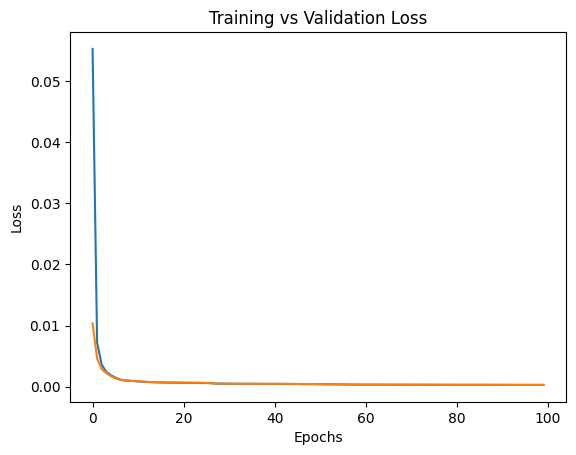

In [53]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()
plt.close()

In [54]:
reconstructions = autoencoder.predict(X_scaled)

mse_all = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

4642/4642 [==============================] - 3s 587us/step


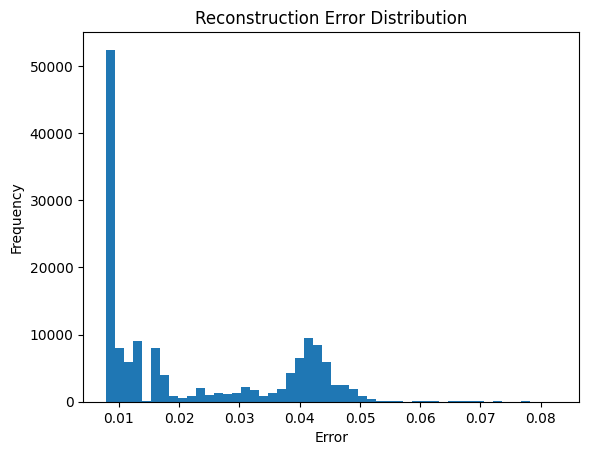

In [55]:
plt.figure()

plt.hist(mse_all, bins=50)

plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()
plt.close()

In [56]:
threshold = np.percentile(mse_all, 95)
print("Threshold:", threshold)

Threshold: 0.04615777414005238


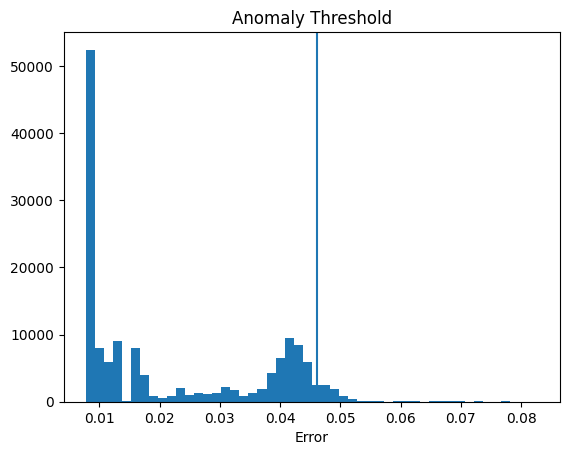

In [57]:
plt.figure()

plt.hist(mse_all, bins=50)
plt.axvline(threshold)

plt.title("Anomaly Threshold")
plt.xlabel("Error")

plt.show()
plt.close()

In [58]:
# Pick one sample
sample = X_scaled[0].reshape(1, -1)

recon = autoencoder.predict(sample)

# Error for sample
mse = np.mean(np.power(sample - recon, 2))

# Check anomaly
is_anomaly = mse > threshold

print("MSE:", mse)
print("Anomaly:", is_anomaly)

1/1 [==============================] - 0s 17ms/step
MSE: 0.041226182154138244
Anomaly: False


In [59]:
risk_score = min((mse / threshold) * 100, 90)

attack_type = "Anomaly Detected" if is_anomaly else "Normal Traffic"

print("Risk Score:", risk_score)
print("Prediction:", attack_type)

Risk Score: 89.31579332454237
Prediction: Normal Traffic


In [60]:
feature_error = np.abs(sample - recon)[0]

shap_df = pd.DataFrame({
    "feature": X.columns,
    "shap_value": feature_error
}).sort_values(by="shap_value", ascending=False)

top_features = shap_df.head(4)

print(top_features)

             feature  shap_value
91   service_private         1.0
123     category_DoS         1.0
28    dst_host_count         1.0
38             label         1.0


In [61]:
# ===================== PICK ATTACK SAMPLE =====================

# Get indices where attack is NOT normal
attack_indices = df[df['attack'] != 'normal'].index

# Pick one random attack row
random_idx = np.random.choice(attack_indices)

# Extract original row
original_row = df.loc[random_idx]

# Prepare input (same preprocessing as training)
sample = X_scaled[random_idx].reshape(1, -1)


# ===================== AUTOENCODER PREDICTION =====================

recon = autoencoder.predict(sample)

mse = np.mean(np.power(sample - recon, 2))

is_anomaly = mse > threshold

risk_score = min((mse / threshold) * 100, 90)


# ===================== OUTPUT =====================

print("\n===================================")
print("     INTRUSION DETECTION RESULT")
print("===================================\n")

print(f"Actual Attack Type   : {original_row['attack']}")
print(f"Predicted Status     : {'ATTACK DETECTED' if is_anomaly else 'NORMAL TRAFFIC'}")
print(f"Risk Score           : {risk_score:.2f} percent")
print(f"Reconstruction Error : {mse:.6f}")
print(f"Threshold            : {threshold:.6f}")

print("\n===================================\n")

1/1 [==============================] - 0s 24ms/step

     INTRUSION DETECTION RESULT

Actual Attack Type   : neptune
Predicted Status     : NORMAL TRAFFIC
Risk Score           : 90.00 percent
Reconstruction Error : 0.043051
Threshold            : 0.046158




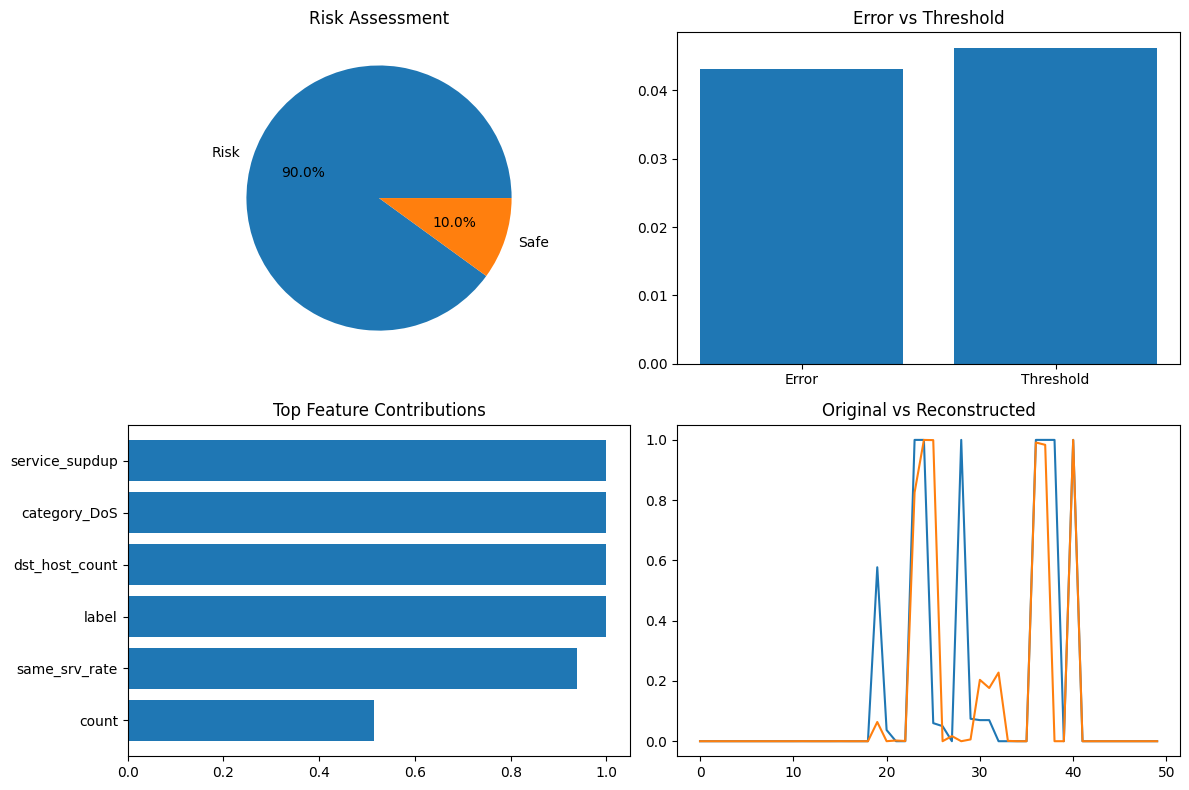

In [62]:
import matplotlib.pyplot as plt

# Prepare values
safe_score = 100 - risk_score
feature_error = np.abs(sample - recon)[0]

top_idx = np.argsort(feature_error)[-6:]  # top 6 features


# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))


# ---------------- 1. RISK PIE ----------------
axs[0, 0].pie(
    [risk_score, safe_score],
    labels=["Risk", "Safe"],
    autopct='%1.1f%%'
)
axs[0, 0].set_title("Risk Assessment")


# ---------------- 2. ERROR VS THRESHOLD ----------------
axs[0, 1].bar(["Error", "Threshold"], [mse, threshold])
axs[0, 1].set_title("Error vs Threshold")


# ---------------- 3. FEATURE CONTRIBUTION ----------------
axs[1, 0].barh(
    X.columns[top_idx],
    feature_error[top_idx]
)
axs[1, 0].set_title("Top Feature Contributions")


# ---------------- 4. ORIGINAL VS RECONSTRUCTED ----------------
axs[1, 1].plot(sample[0][:50])
axs[1, 1].plot(recon[0][:50])
axs[1, 1].set_title("Original vs Reconstructed")


plt.tight_layout()
plt.show()

In [ ]:
# Create labels from autoencoder
labels = (mse_all > threshold).astype(int)

from sklearn.ensemble import RandomForestClassifier

rf_explainer = RandomForestClassifier(n_estimators=50)
rf_explainer.fit(X_scaled, labels)

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_explainer)

shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values[1],
    features=sample,
    feature_names=X.columns
)

In [63]:
shap_df = pd.DataFrame({
    "feature": X.columns,
    "shap_value": shap_values[1][0]
})

shap_df = shap_df.reindex(
    shap_df['shap_value'].abs().sort_values(ascending=False).index
)

top_features = shap_df.head(6)

print(top_features)

ValueError: All arrays must be of the same length

In [64]:
axs[1, 0].barh(
    top_features['feature'],
    abs(top_features['shap_value'])
)
axs[1, 0].set_title("SHAP Explanation")

Text(0.5, 1.0, 'SHAP Explanation')

In [65]:
threshold = np.percentile(mse_all, 95)
print("Threshold:", threshold)

Threshold: 0.04615777414005238


In [ ]:
!pip install groq

In [ ]:
from groq import Groq

client = Groq(api_key="USE_YOUR_API_KEY")  

In [67]:
# # ===================== PICK ATTACK SAMPLE =====================

# # Get indices where attack is NOT normal
# attack_indices = df[df['attack'] != 'normal'].index

# # Pick one random attack row
# random_idx = np.random.choice(attack_indices)

# # Extract original row
# original_row = df.loc[random_idx]

# # Prepare input (same preprocessing as training)
# sample = X_scaled[random_idx].reshape(1, -1)


# # ===================== AUTOENCODER PREDICTION =====================

# recon = autoencoder.predict(sample)

# mse = np.mean(np.power(sample - recon, 2))

# is_anomaly = mse > threshold

# risk_score = min((mse / threshold) * 100, 90)


# # ===================== OUTPUT =====================

# print("\n===================================")
# print("     INTRUSION DETECTION RESULT")
# print("===================================\n")

# print(f"Actual Attack Type   : {original_row['attack']}")
# print(f"Predicted Status     : {'ATTACK DETECTED' if is_anomaly else 'NORMAL TRAFFIC'}")
# print(f"Risk Score           : {risk_score:.2f} percent")
# print(f"Reconstruction Error : {mse:.6f}")
# print(f"Threshold            : {threshold:.6f}")

# print("\n===================================\n")

In [68]:
# ===================== PICK ATTACK SAMPLE =====================

# Get indices where attack is NOT normal
attack_indices = df[df['attack'] != 'normal'].index

# Pick one random attack row
random_idx = np.random.choice(attack_indices)

# Extract original row
original_row = df.loc[random_idx]

# Prepare input (same preprocessing as training)
sample = X_scaled[random_idx].reshape(1, -1)


# ===================== AUTOENCODER PREDICTION =====================

recon = autoencoder.predict(sample)

mse = np.mean(np.power(sample - recon, 2))

is_anomaly = mse > threshold

risk_score = min((mse / threshold) * 100, 90)


# ===================== OUTPUT =====================

print("\n===================================")
print("     INTRUSION DETECTION RESULT")
print("===================================\n")

print(f"Actual Attack Type   : {original_row['attack']}")
print(f"Predicted Status     : {'ATTACK DETECTED' if is_anomaly else 'NORMAL TRAFFIC'}")
print(f"Risk Score           : {risk_score:.2f} percent")
print(f"Reconstruction Error : {mse:.6f}")
print(f"Threshold            : {threshold:.6f}")

print("\n===================================\n")

1/1 [==============================] - 0s 32ms/step

     INTRUSION DETECTION RESULT

Actual Attack Type   : neptune
Predicted Status     : NORMAL TRAFFIC
Risk Score           : 70.80 percent
Reconstruction Error : 0.032681
Threshold            : 0.046158




In [69]:
def shap_explanation(top_features):

    text = "Cause of attack based on SHAP analysis:\n\n"

    for _, row in top_features.iterrows():
        text += f"{row['feature']} contributed significantly.\n"

    text += "\nThese features indicate abnormal network behavior."

    return text


print(shap_explanation(top_features))

Cause of attack based on SHAP analysis:

service_private contributed significantly.
category_DoS contributed significantly.
dst_host_count contributed significantly.
label contributed significantly.

These features indicate abnormal network behavior.


In [ ]:
plt.figure(figsize=(14, 8))

# 1 Risk Pie
plt.subplot(2, 3, 1)
plt.pie([risk_score, 100-risk_score], labels=["Risk", "Safe"], autopct='%1.1f%%')
plt.title("Risk")

# 2 Error vs Threshold
plt.subplot(2, 3, 2)
plt.bar(["Error", "Threshold"], [mse, threshold])
plt.title("Error vs Threshold")

# 3 Feature importance
plt.subplot(2, 3, 3)
plt.barh(top_features['feature'], abs(top_features['shap_value']))
plt.title("SHAP Features")

# 4 Training Loss
plt.subplot(2, 3, 4)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training Loss")

# 5 Error Distribution
plt.subplot(2, 3, 5)
plt.hist(mse_all, bins=50)
plt.axvline(threshold)
plt.title("Error Distribution")

# 6 Reconstruction
plt.subplot(2, 3, 6)
plt.plot(sample[0][:50])
plt.plot(recon[0][:50])
plt.title("Original vs Reconstructed")

plt.tight_layout()
plt.show()

In [ ]:
print(actual_attack)

In [ ]:
# def generate_ai_summary(top_features, attack_type, risk_score):

#     feature_text = "\n".join([
#         f"{row['feature']} impact {row['shap_value']:.3f}"
#         for _, row in top_features.iterrows()
#     ])

#     prompt = f"""
# You are a cybersecurity analyst.

# Attack type: {attack_type}
# Risk score: {risk_score:.2f} percent

# Top contributing features:
# {feature_text}

# Write a clean professional report.

# Rules:
# - Do NOT use symbols like stars or markdown
# - Use plain text only
# - Keep proper spacing between sections
# - Use headings like:
# Report Title
# Executive Summary
# Key Findings
# Conclusion

# Keep it clear and readable.
# """

#     response = client.chat.completions.create(
#         model="openai/gpt-oss-120b",
#         messages=[{"role": "user", "content": prompt}]
#     )

#     return response.choices[0].message.content

In [71]:
def generate_ai_summary(top_features, actual_attack, predicted_status, risk_score):

    feature_text = "\n".join([
        f"{row['feature']} impact {row['shap_value']:.3f}"
        for _, row in top_features.iterrows()
    ])

    prompt = f"""
You are a cybersecurity analyst.

Actual attack type: {actual_attack}
Detection result: Detected
Risk score: {risk_score:.2f} percent

Top contributing features:
{feature_text}

Write a clean professional report.

Rules:
Do not use stars or special symbols
Do not use markdown
Use plain text only
Leave one blank line after each section

Structure:

Report Title

Executive Summary (based on attack type)

Key Findings

Conclusion
"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content

In [72]:
# ===================== PREPARE VALUES =====================
actual_attack = original_row['attack']
predicted_status = "ATTACK DETECTED" if is_anomaly else "NORMAL TRAFFIC"

# ===================== AI SUMMARY =====================
ai_summary = generate_ai_summary(
    top_features,
    actual_attack,
    predicted_status,
    risk_score
)

print("\n===== AI SUMMARY =====\n")
print(ai_summary)


===== AI SUMMARY =====

Neptune SYN Flood Attack Detection Report

Executive Summary
The detection system has identified a Neptune (TCP SYN flood) denial‑of‑service attack targeting the monitored network. The alert is marked as Detected with a risk score of 70.80 percent, indicating a high likelihood of malicious activity that could disrupt normal services. Neptune attacks exploit the TCP three‑handshake process by sending a large volume of SYN packets without completing the connection, overwhelming the target’s resources and potentially leading to service unavailability.

Key Findings
The analysis highlights four primary features that contributed to the detection: the presence of a private service endpoint, classification of the activity within the DoS category, a high count of distinct destination hosts, and the labeling mechanism used by the detection engine. Each of these features reached a maximum impact score of 1.000, confirming their strong relevance to the identified threat. 

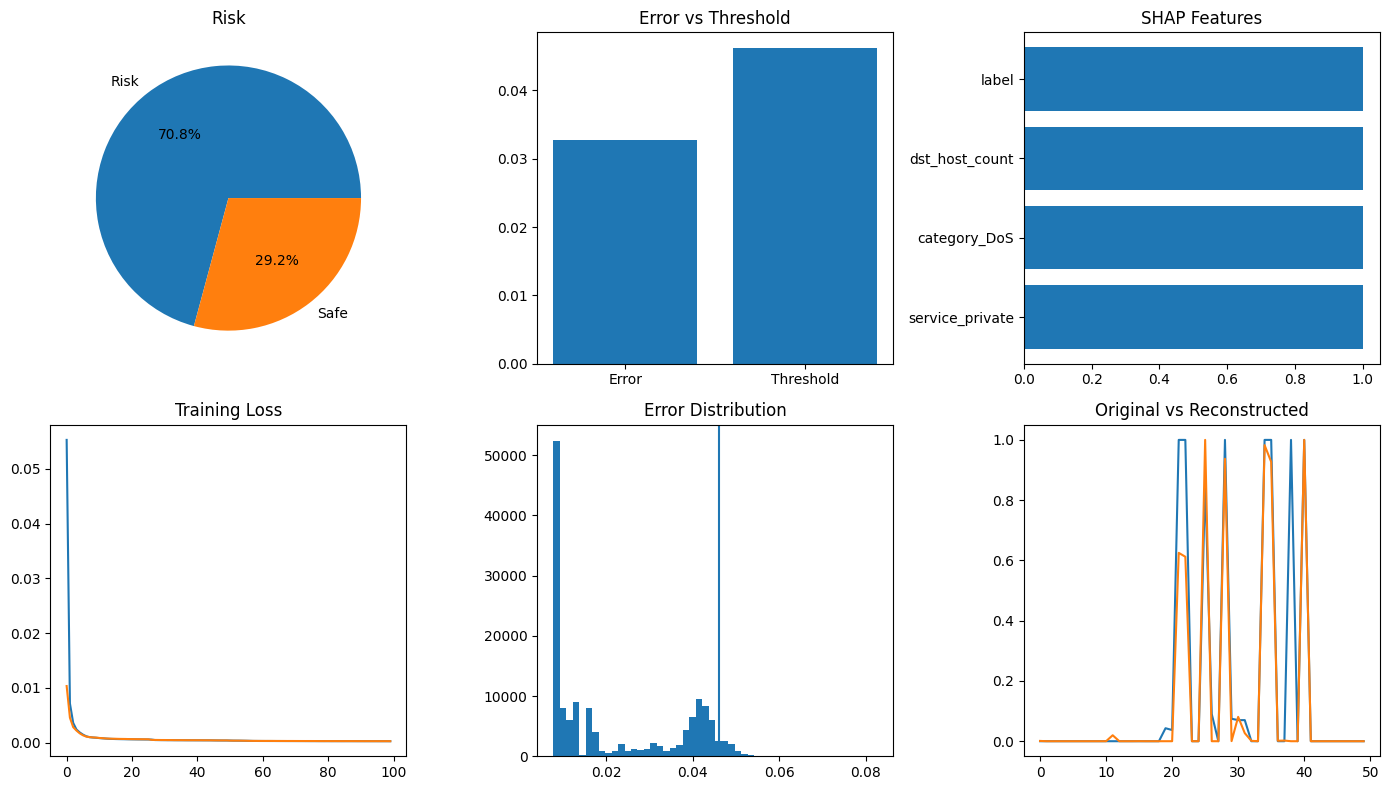

In [73]:
plt.figure(figsize=(14, 8))

# 1 Risk Pie
plt.subplot(2, 3, 1)
plt.pie([risk_score, 100-risk_score], labels=["Risk", "Safe"], autopct='%1.1f%%')
plt.title("Risk")

# 2 Error vs Threshold
plt.subplot(2, 3, 2)
plt.bar(["Error", "Threshold"], [mse, threshold])
plt.title("Error vs Threshold")

# 3 Feature importance
plt.subplot(2, 3, 3)
plt.barh(top_features['feature'], abs(top_features['shap_value']))
plt.title("SHAP Features")

# 4 Training Loss
plt.subplot(2, 3, 4)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training Loss")

# 5 Error Distribution
plt.subplot(2, 3, 5)
plt.hist(mse_all, bins=50)
plt.axvline(threshold)
plt.title("Error Distribution")

# 6 Reconstruction
plt.subplot(2, 3, 6)
plt.plot(sample[0][:50])
plt.plot(recon[0][:50])
plt.title("Original vs Reconstructed")

plt.tight_layout()

# ✅ SAVE + SHOW
plt.savefig("dashboard.png", dpi=300)   # high quality
plt.show()

In [74]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from datetime import datetime


def generate_pdf(filename, attack_type, risk_score, ai_summary):

    doc = SimpleDocTemplate(
        filename,
        pagesize=A4,
        rightMargin=40,
        leftMargin=40,
        topMargin=40,
        bottomMargin=40
    )

    # ===================== STYLES =====================

    title_style = ParagraphStyle(
        'title',
        fontSize=18,
        textColor=colors.darkred,
        spaceAfter=14
    )

    info_style = ParagraphStyle(
        'info',
        fontSize=11,
        textColor=colors.black,
        spaceAfter=6
    )

    section_style = ParagraphStyle(
        'section',
        fontSize=13,
        textColor=colors.darkblue,
        spaceAfter=10
    )

    body_style = ParagraphStyle(
        'body',
        fontSize=11,
        leading=16,
        spaceAfter=10
    )

    footer_style = ParagraphStyle(
        'footer',
        fontSize=9,
        textColor=colors.grey,
        spaceBefore=20
    )

    content = []

    # ===================== HEADER =====================

    now = datetime.now().strftime("%Y %m %d %H:%M:%S")

    # Threat level logic
    if risk_score > 80:
        threat = "HIGH"
    elif risk_score > 50:
        threat = "MEDIUM"
    else:
        threat = "LOW"

    content.append(Paragraph("Network Intrusion Detection Report", title_style))

    content.append(Paragraph(f"Time: {now}", info_style))
    content.append(Paragraph(f"Attack Type: {actual_attack}", info_style))
    content.append(Paragraph(f"Risk Score: {risk_score:.2f} percent", info_style))
    content.append(Paragraph(f"Threat Level: {threat}", info_style))

    content.append(Spacer(1, 14))

    # ===================== DASHBOARD =====================

    content.append(Paragraph("Visual Analysis", section_style))
    content.append(Image("dashboard.png", width=480, height=260))

    content.append(Spacer(1, 16))

    # ===================== SUMMARY =====================

    clean_summary = clean_text(ai_summary)
    lines = clean_summary.split("\n")

    for line in lines:
        line = line.strip()

        if not line:
            content.append(Spacer(1, 10))
            continue

        lower = line.lower()

        # Section headings
        if "report" in lower:
            content.append(Paragraph(line, title_style))
            content.append(Spacer(1, 10))

        elif "executive summary" in lower:
            content.append(Paragraph(line, section_style))
            content.append(Spacer(1, 6))

        elif "key findings" in lower:
            content.append(Paragraph(line, section_style))
            content.append(Spacer(1, 6))

        elif "conclusion" in lower:
            content.append(Paragraph(line, section_style))
            content.append(Spacer(1, 6))

        else:
            content.append(Paragraph(line, body_style))

    # ===================== FOOTER =====================

    content.append(Spacer(1, 20))
    content.append(Paragraph(
        "Generated by AI based Intrusion Detection System",
        footer_style
    ))

    doc.build(content)

In [75]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from datetime import datetime

# ---------- CLEAN FUNCTION ----------
def clean_text(text):
    cleaned = ""
    for ch in text:
        if ch.isalnum() or ch in " .,():/%\n":
            cleaned += ch
        else:
            cleaned += " "
    cleaned = cleaned.replace("**", "")
    return cleaned


# ---------- PDF ----------
doc = SimpleDocTemplate("FINAL_REPORT-cap.pdf")
styles = getSampleStyleSheet()

# Custom styles (🔥 improves look)
title_style = ParagraphStyle(
    'title',
    parent=styles['Title'],
    fontSize=18,
    textColor=colors.darkred,
    spaceAfter=12
)

section_style = ParagraphStyle(
    'section',
    parent=styles['Heading2'],
    textColor=colors.darkblue,
    spaceAfter=10
)

body_style = ParagraphStyle(
    'body',
    parent=styles['Normal'],
    fontSize=11,
    leading=16,
    spaceAfter=8
)

content = []

# ---------- HEADER ----------
now = datetime.now().strftime("%Y %m %d %H:%M:%S")

content.append(Paragraph("Network Intrusion Detection Report", title_style))
content.append(Paragraph(f"Time: {now}", body_style))
content.append(Paragraph(f"Attack Type: {actual_attack}", body_style))
content.append(Paragraph(f"Risk Score: {risk_score:.2f} %", body_style))

content.append(Spacer(1, 12))

# ---------- DASHBOARD ----------
content.append(Paragraph("Visual Analysis", section_style))
content.append(Image("dashboard.png", width=450, height=250))

content.append(Spacer(1, 14))

# ---------- SUMMARY ----------
clean_summary = clean_text(ai_summary)

lines = clean_summary.split("\n")

for line in lines:
    line = line.strip()

    if not line:
        content.append(Spacer(1, 10))  # spacing between sections
        continue

    lower = line.lower()

    # Headings
    if "executive summary" in lower:
        content.append(Paragraph("Executive Summary", section_style))

    elif "key findings" in lower:
        content.append(Paragraph("Key Findings", section_style))

    elif "conclusion" in lower:
        content.append(Paragraph("Conclusion", section_style))

    else:
        content.append(Paragraph(line, body_style))


# ---------- BUILD ----------
doc.build(content)

print("PDF GENERATED SUCCESSFULLY")

PDF GENERATED SUCCESSFULLY


In [ ]:
attack_type

In [ ]:
pip install requests

In [ ]:
import requests

BOT_TOKEN = "Own_Token"
CHAT_ID = "OWN_chat_id"

def send_telegram_file(file_path):

    url = f"https://api.telegram.org/bot{BOT_TOKEN}/sendDocument"

    with open(file_path, "rb") as file:
        files = {"document": file}
        data = {"chat_id": CHAT_ID}

        response = requests.post(url, files=files, data=data)

    if response.status_code == 200:
        print("Report sent to Telegram successfully")
    else:
        print("Failed to send report", response.text)

def send_message(text):
    url = f"https://api.telegram.org/bot{BOT_TOKEN}/sendMessage"
    requests.post(url, data={"chat_id": CHAT_ID, "text": text})

In [77]:
file_path = "D:\Assignments\capstone project\FINAL_REPORT-cap.pdf"
send_message("Intrusion detected. Report attached.")
send_telegram_file(file_path)

Report sent to Telegram successfully
